# Explainable AI Email Triage: Week 4 Model Optimization

## tl;dr

I used a bounded Week 4 search to improve the Week 3 urgency model without
rewriting the baseline. The selected candidate improved mean five-fold
cross-validation urgent F1 from 6.7% to 11.4% and urgent recall from 4.0% to
8.0%. On the earlier 40-message holdout, it matched the frozen baseline: 87.5%
accuracy, 66.7% urgent precision, 33.3% urgent recall, 44.4% urgent F1, and
four urgent false negatives. The candidate uses fewer features (2,895 instead
of 4,097), so I retained it for further refinement. It is not deployment-ready.

The holdout result remains preliminary because that split informed the Week 3
exploratory comparison.

## Context & Methods

I kept the submitted Week 3 baseline intact and used this notebook for a
focused Week 4 optimization and explainability study. The notebook uses the
same reviewed 199-message label manifest and the Week 3 80/20 split. I select
the candidate only through five-fold stratified cross-validation on the
159-message training partition. I then use the 40-message holdout once as a
clearly labeled preliminary comparison.

### Key Assumptions

- Urgent-class F1 is the primary selection measure. Urgent recall and false
  negatives remain the most important safety checks.
- The approved labels, source text, and Week 3 split are fixed inputs.
- The label manifest does not contain demographic attributes, so this study
  cannot support demographic fairness claims.
- Exports contain identifiers and aggregate evidence, not email bodies.

## 1. Setup and Reproducibility

In [1]:
# I load the fixed analysis stack before touching the data.
# Printing versions gives a later reader the information needed to reproduce this run.
import sys
import time
import warnings
from email import policy
from email.parser import Parser
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore", message="IProgress not found.*")
import shap
import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("SHAP:", shap.__version__)

Python: 3.11.8
pandas: 3.0.3
scikit-learn: 1.9.0
SHAP: 0.51.0


In [2]:
# I keep these values fixed so Week 4 stays comparable with Week 3.
# I do not change them to chase a more favorable result.
SEED = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
LABEL_ORDER = ["nonurgent", "urgent"]

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA = PROJECT_ROOT / "data" / "raw" / "emails.csv"
LABEL_MANIFEST = PROJECT_ROOT / "data" / "labels" / "enron_urgency_labels_v1.csv"
METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

missing_inputs = [path for path in (RAW_DATA, LABEL_MANIFEST) if not path.exists()]
if missing_inputs:
    raise FileNotFoundError("Missing required input(s): " + ", ".join(map(str, missing_inputs)))

print("Repository root: .")
print("Raw data:", RAW_DATA.relative_to(PROJECT_ROOT))
print("Label manifest:", LABEL_MANIFEST.relative_to(PROJECT_ROOT))

Repository root: .
Raw data: data/raw/emails.csv
Label manifest: data/labels/enron_urgency_labels_v1.csv


## 2. Load and Validate the Reviewed Modeling Data

## Data

The reviewed label manifest defines the 199-message modeling population. The
raw Enron file provides only the matching source text. Keeping those roles
separate preserves the reviewed labels while avoiding unnecessary email content
in repository exports.

In [3]:
# The reviewed manifest is the label source of truth. These checks stop silent label drift.
approved_labels = pd.read_csv(LABEL_MANIFEST)
assert len(approved_labels) == 199
assert approved_labels["message_id"].is_unique
assert approved_labels["review_status"].eq("Reviewed").all()
assert set(approved_labels["urgency_label"]) == set(LABEL_ORDER)

# I scan only the 199 reviewed records from the 1.3 GB source file to limit memory use and exposure.
requested_ids = set(approved_labels["message_id"])
source_rows = []
for chunk in pd.read_csv(RAW_DATA, usecols=["file", "message"], chunksize=10_000):
    matched = chunk.loc[chunk["file"].isin(requested_ids)]
    if not matched.empty:
        source_rows.append(matched)

raw_modeling_rows = pd.concat(source_rows, ignore_index=True)
assert raw_modeling_rows["file"].is_unique
assert set(raw_modeling_rows["file"]) == requested_ids
print("Recovered reviewed source records:", len(raw_modeling_rows))

Recovered reviewed source records: 199


In [4]:
# I reuse the Week 3 parser so Week 4 changes model selection, not the text contract.
def parse_email(raw_message):
    parsed = Parser(policy=policy.default).parsestr(raw_message)
    subject = str(parsed.get("subject", "")).strip()
    try:
        if parsed.is_multipart():
            body_part = parsed.get_body(preferencelist=("plain",))
            body = body_part.get_content() if body_part else ""
        else:
            body = parsed.get_content()
    except Exception:
        body = str(parsed.get_payload())
    return f"{subject}\n\n{str(body).strip()}".strip()

raw_modeling_rows["combined_text"] = raw_modeling_rows["message"].map(parse_email)
modeling_data = (
    approved_labels[["message_id", "sampling_stratum", "urgency_label"]]
    .merge(
        raw_modeling_rows[["file", "combined_text"]],
        left_on="message_id",
        right_on="file",
        how="inner",
        validate="one_to_one",
    )
    .drop(columns="file")
)
assert modeling_data["combined_text"].str.strip().ne("").all()
label_summary = modeling_data["urgency_label"].value_counts().rename("records").to_frame()
display(label_summary)

,records
urgency_label,
nonurgent,169
urgent,30


## 3. Recreate the Frozen Week 3 Split

In [5]:
# I preserve the Week 3 split for a descriptive comparison.
# Model selection below uses only the training partition; I do not tune on the holdout.
X_train, X_holdout, y_train, y_holdout = train_test_split(
    modeling_data["combined_text"],
    modeling_data["urgency_label"],
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=modeling_data["urgency_label"],
)
split_summary = pd.DataFrame({"train": y_train.value_counts(), "holdout": y_holdout.value_counts()}).fillna(0).astype(int)
split_summary.loc["total"] = split_summary.sum()
display(split_summary)
split_summary.rename_axis("class").reset_index().to_csv(METRICS_DIR / "week4_split_summary.csv", index=False)

,train,holdout
urgency_label,,
nonurgent,135,34
urgent,24,6
total,159,40


### Exact-Duplicate Grouping Check

I check for exact normalized-text duplicates because a duplicate crossing the
training and holdout partitions could make the preliminary comparison look
better than it is. This is a narrow check. It does not identify near duplicates,
reply chains, or shared threads, so those remain explicit limitations.

In [6]:
# I check exact normalized-text overlap without exporting message bodies.
import hashlib
import re


def text_fingerprint(text):
    normalized = re.sub(r"\s+", " ", str(text).lower()).strip()
    return hashlib.sha256(normalized.encode("utf-8")).hexdigest()


train_fingerprints = pd.DataFrame({
    "message_id_train": modeling_data.loc[X_train.index, "message_id"],
    "fingerprint": X_train.map(text_fingerprint),
})
holdout_fingerprints = pd.DataFrame({
    "message_id_holdout": modeling_data.loc[X_holdout.index, "message_id"],
    "fingerprint": X_holdout.map(text_fingerprint),
})
exact_cross_split_duplicates = train_fingerprints.merge(
    holdout_fingerprints,
    on="fingerprint",
    how="inner",
    validate="many_to_many",
)
grouping_risk = pd.DataFrame([{
    "check": "exact normalized-text fingerprints across training and holdout",
    "training_records": len(train_fingerprints),
    "holdout_records": len(holdout_fingerprints),
    "cross_split_exact_duplicate_pairs": len(exact_cross_split_duplicates),
    "limitation": "Near duplicates, reply chains, and related messages are not identified by this exact-match check.",
}])
grouping_risk.to_csv(METRICS_DIR / "week4_grouping_risk.csv", index=False)
display(grouping_risk)
if not exact_cross_split_duplicates.empty:
    display(exact_cross_split_duplicates[["message_id_train", "message_id_holdout"]])

,check,training_records,holdout_records,cross_split_exact_duplicate_pairs,limitation
0,exact normalized-text fingerprints across trai...,159,40,0,"Near duplicates, reply chains, and related mes..."


## 4. Define the Baseline, Scoring, and Bounded Search

In [7]:
# I keep TF-IDF inside the pipeline so each CV fold fits features only on its own training data.
def make_pipeline(**classifier_overrides):
    classifier_parameters = {
        "class_weight": "balanced",
        "max_iter": 1_000,
        "random_state": SEED,
        **classifier_overrides,
    }
    return Pipeline([
        ("tfidf", TfidfVectorizer(lowercase=True, stop_words="english", ngram_range=(1, 2), min_df=2)),
        ("classifier", LogisticRegression(**classifier_parameters)),
    ])

scoring = {
    "accuracy": "accuracy",
    "precision_urgent": make_scorer(precision_score, pos_label="urgent", zero_division=0),
    "recall_urgent": make_scorer(recall_score, pos_label="urgent", zero_division=0),
    "f1_urgent": make_scorer(f1_score, pos_label="urgent", zero_division=0),
}
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
baseline_model = make_pipeline()
# This 24-run grid demonstrates tuning and feature engineering without an unbounded search.
parameter_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2],
    "tfidf__sublinear_tf": [False, True],
    "classifier__C": [0.1, 1.0, 10.0],
}
grid_size = int(np.prod([len(values) for values in parameter_grid.values()]))
print(f"Grid configurations: {grid_size}; CV fits: {grid_size * CV_FOLDS}")

Grid configurations: 24; CV fits: 120


## 5. Cross-Validate the Baseline and Tune the Candidate

## Results

The evidence has a fixed order. Cross-validation selects the candidate. The
frozen Week 3 holdout then provides a preliminary comparison. I do not use
accuracy alone to make the continuation decision because it can hide missed
urgent messages.

### Predefined Selection Rule

I select the candidate with the strongest mean urgent F1 in five-fold
cross-validation. I keep it only if its preliminary holdout urgent F1, urgent
recall, and urgent false-negative count do not worsen from the frozen baseline.

In [8]:
# I establish the frozen baseline's CV distribution before examining tuned candidates.
baseline_cv = cross_validate(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1,
)

baseline_cv_summary = {
    "model": "Frozen Week 3 class-balanced baseline",
    **{f"cv_mean_{metric}": float(np.mean(baseline_cv[f"test_{metric}"])) for metric in scoring},
    **{f"cv_std_{metric}": float(np.std(baseline_cv[f"test_{metric}"], ddof=1)) for metric in scoring},
    "mean_fit_time_seconds": float(np.mean(baseline_cv["fit_time"])),
    "mean_score_time_seconds": float(np.mean(baseline_cv["score_time"])),
}

# I use urgent F1 as the refit score because accuracy alone can hide missed urgent messages.
search = GridSearchCV(
    estimator=make_pipeline(),
    param_grid=parameter_grid,
    scoring=scoring,
    refit="f1_urgent",
    cv=cv,
    n_jobs=-1,
    return_train_score=False,
)
search_started = time.perf_counter()
search.fit(X_train, y_train)
search_elapsed_seconds = time.perf_counter() - search_started
print("Best parameters:", search.best_params_)
print("Best urgent F1:", round(search.best_score_, 3))
print("Grid-search elapsed seconds:", round(search_elapsed_seconds, 2))

Best parameters: {'classifier__C': 0.1, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1), 'tfidf__sublinear_tf': True}
Best urgent F1: 0.114
Grid-search elapsed seconds: 3.63


In [9]:
# I export every tested configuration, not only the winner, so the comparison remains traceable.
cv_results = pd.DataFrame(search.cv_results_)
experiment_results = cv_results[[
    "params", "rank_test_f1_urgent", "mean_test_accuracy", "std_test_accuracy",
    "mean_test_precision_urgent", "std_test_precision_urgent",
    "mean_test_recall_urgent", "std_test_recall_urgent",
    "mean_test_f1_urgent", "std_test_f1_urgent", "mean_fit_time", "mean_score_time",
]].copy()
experiment_results.insert(0, "run_id", [f"week4-grid-{index + 1:02d}" for index in range(len(experiment_results))])
experiment_results.insert(1, "data_version", "enron_urgency_labels_v1")
experiment_results.insert(2, "selection_metric", "urgent_f1")
experiment_results = experiment_results.sort_values("rank_test_f1_urgent").reset_index(drop=True)
experiment_results.to_csv(METRICS_DIR / "week4_experiment_results.csv", index=False)
display(experiment_results.head(10))

,run_id,data_version,selection_metric,params,rank_test_f1_urgent,mean_test_accuracy,std_test_accuracy,mean_test_precision_urgent,std_test_precision_urgent,mean_test_recall_urgent,std_test_recall_urgent,mean_test_f1_urgent,std_test_f1_urgent,mean_fit_time,mean_score_time
0,week4-grid-22,enron_urgency_labels_v1,urgent_f1,"{'classifier__C': 10.0, 'tfidf__min_df': 2, 't...",1,0.861694,0.024646,0.20,0.4,0.08,0.16000,0.114286,0.228571,0.063321,0.029110
1,week4-grid-06,enron_urgency_labels_v1,urgent_f1,"{'classifier__C': 0.1, 'tfidf__min_df': 2, 'tf...",1,0.861694,0.024646,0.20,0.4,0.08,0.16000,0.114286,0.228571,0.055336,0.023286
2,week4-grid-14,enron_urgency_labels_v1,urgent_f1,"{'classifier__C': 1.0, 'tfidf__min_df': 2, 'tf...",1,0.861694,0.024646,0.20,0.4,0.08,0.16000,0.114286,0.228571,0.061370,0.026041
3,week4-grid-05,enron_urgency_labels_v1,urgent_f1,"{'classifier__C': 0.1, 'tfidf__min_df': 2, 'tf...",4,0.830444,0.030784,0.15,0.2,0.08,0.09798,0.101587,0.126028,0.057593,0.028022
4,week4-grid-07,enron_urgency_labels_v1,urgent_f1,"{'classifier__C': 0.1, 'tfidf__min_df': 2, 'tf...",4,0.824194,0.030620,0.15,0.2,0.08,0.09798,0.101587,0.126028,0.095216,0.029616
5,week4-grid-24,enron_urgency_labels_v1,urgent_f1,"{'classifier__C': 10.0, 'tfidf__min_df': 2, 't...",6,0.855444,0.014378,0.20,0.4,0.04,0.08000,0.066667,0.133333,0.135999,0.033853
6,week4-grid-21,enron_urgency_labels_v1,urgent_f1,"{'classifier__C': 10.0, 'tfidf__min_df': 2, 't...",6,0.849194,0.022564,0.20,0.4,0.04,0.08000,0.066667,0.133333,0.062890,0.028133
7,week4-grid-08,enron_urgency_labels_v1,urgent_f1,"{'classifier__C': 0.1, 'tfidf__min_df': 2, 'tf...",6,0.855444,0.014378,0.20,0.4,0.04,0.08000,0.066667,0.133333,0.095616,0.032067
8,week4-grid-23,enron_urgency_labels_v1,urgent_f1,"{'classifier__C': 10.0, 'tfidf__min_df': 2, 't...",6,0.849194,0.022564,0.20,0.4,0.04,0.08000,0.066667,0.133333,0.112054,0.041154
9,week4-grid-13,enron_urgency_labels_v1,urgent_f1,"{'classifier__C': 1.0, 'tfidf__min_df': 2, 'tf...",6,0.842944,0.033527,0.20,0.4,0.04,0.08000,0.066667,0.133333,0.057882,0.031871


## 6. Evaluate the Frozen Baseline and Selected Candidate

In [10]:
# I freeze the cross-validation winner before the single descriptive holdout comparison.
selected_model = search.best_estimator_

# I evaluate both models with the same holdout metrics and lightweight efficiency checks.
def fit_and_evaluate(model_name, estimator):
    fit_started = time.perf_counter()
    estimator.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - fit_started
    score_started = time.perf_counter()
    predictions = estimator.predict(X_holdout)
    score_seconds = time.perf_counter() - score_started
    matrix = confusion_matrix(y_holdout, predictions, labels=LABEL_ORDER)
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_holdout, predictions),
        "urgent_precision": precision_score(y_holdout, predictions, pos_label="urgent", zero_division=0),
        "urgent_recall": recall_score(y_holdout, predictions, pos_label="urgent", zero_division=0),
        "urgent_f1": f1_score(y_holdout, predictions, pos_label="urgent", zero_division=0),
        "urgent_false_negatives": int(matrix[1, 0]),
        "fit_seconds": fit_seconds,
        "score_seconds": score_seconds,
        "feature_count": int(len(estimator.named_steps["tfidf"].get_feature_names_out())),
        "predictions": predictions,
        "confusion_matrix": matrix,
        "estimator": estimator,
    }

baseline_evaluation = fit_and_evaluate("Frozen Week 3 class-balanced baseline", make_pipeline())
selected_evaluation = fit_and_evaluate("Week 4 GridSearchCV candidate", selected_model)
evaluations = [baseline_evaluation, selected_evaluation]

comparison = pd.DataFrame([{key: value for key, value in result.items() if key not in {"predictions", "confusion_matrix", "estimator"}} for result in evaluations])
comparison.to_csv(METRICS_DIR / "week4_model_comparison.csv", index=False)
display(comparison)

,model,accuracy,urgent_precision,urgent_recall,urgent_f1,urgent_false_negatives,fit_seconds,score_seconds,feature_count
0,Frozen Week 3 class-balanced baseline,0.875,0.666667,0.333333,0.444444,4,0.077484,0.012801,4097
1,Week 4 GridSearchCV candidate,0.875,0.666667,0.333333,0.444444,4,0.037036,0.008495,2895


In [11]:
# I show cross-validation and holdout evidence together, but I keep their purposes separate.
selected_cv_summary = {
    "model": "Week 4 GridSearchCV candidate",
    **{f"cv_mean_{metric}": float(search.cv_results_[f"mean_test_{metric}"][search.best_index_]) for metric in scoring},
    **{f"cv_std_{metric}": float(search.cv_results_[f"std_test_{metric}"][search.best_index_]) for metric in scoring},
    "mean_fit_time_seconds": float(search.cv_results_["mean_fit_time"][search.best_index_]),
    "mean_score_time_seconds": float(search.cv_results_["mean_score_time"][search.best_index_]),
}
cv_summary = pd.DataFrame([baseline_cv_summary, selected_cv_summary])
cv_summary.to_csv(METRICS_DIR / "week4_cv_summary.csv", index=False)
display(cv_summary)

metric_deltas = comparison.iloc[1].drop(labels="model") - comparison.iloc[0].drop(labels="model")
metric_deltas.rename("optimized_minus_baseline").to_frame().to_csv(METRICS_DIR / "week4_metric_deltas.csv")
display(metric_deltas.rename("optimized_minus_baseline").to_frame())

,model,cv_mean_accuracy,cv_mean_precision_urgent,cv_mean_recall_urgent,cv_mean_f1_urgent,cv_std_accuracy,cv_std_precision_urgent,cv_std_recall_urgent,cv_std_f1_urgent,mean_fit_time_seconds,mean_score_time_seconds
0,Frozen Week 3 class-balanced baseline,0.836694,0.2,0.04,0.066667,0.050640,0.447214,0.089443,0.149071,0.079075,0.020242
1,Week 4 GridSearchCV candidate,0.861694,0.2,0.08,0.114286,0.024646,0.400000,0.160000,0.228571,0.055336,0.023286


,optimized_minus_baseline
accuracy,0.0
urgent_precision,0.0
urgent_recall,0.0
urgent_f1,0.0
urgent_false_negatives,0
fit_seconds,-0.040448
score_seconds,-0.004306
feature_count,-1202


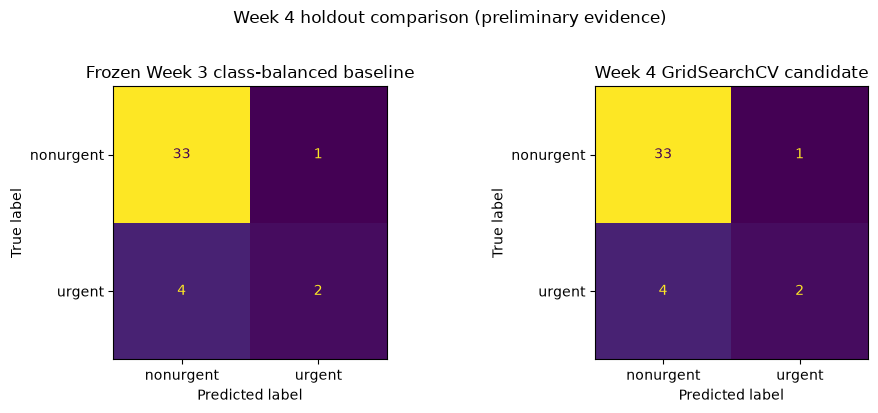

In [12]:
# I use matching labels in both confusion matrices so the error tradeoffs stay visible.
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
for axis, result in zip(axes, evaluations):
    ConfusionMatrixDisplay(result["confusion_matrix"], display_labels=LABEL_ORDER).plot(ax=axis, colorbar=False)
    axis.set_title(result["model"])
figure.suptitle("Week 4 holdout comparison (preliminary evidence)", y=1.02)
figure.tight_layout()
figure.savefig(FIGURES_DIR / "week4_confusion_matrices.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Review Errors Without Exporting Email Bodies

In [13]:
# I keep the exported error analysis to IDs and reviewed categories; I do not export email bodies.
error_pattern_map = {
    "beck-s/all_documents/208.": "deadline_or_administrative_request",
    "mclaughlin-e/all_documents/417.": "explicit_urgency_and_deadline",
    "ermis-f/all_documents/294.": "operational_outage_context",
    "guzman-m/discussion_threads/367.": "technical_or_forwarded_notice",
}
selected_predictions = selected_evaluation["predictions"]
error_analysis = modeling_data.loc[X_holdout.index, ["message_id", "urgency_label"]].copy()
error_analysis["predicted_label"] = selected_predictions
error_analysis["error_type"] = np.select(
    [
        (error_analysis["urgency_label"] == "urgent") & (error_analysis["predicted_label"] == "nonurgent"),
        (error_analysis["urgency_label"] == "nonurgent") & (error_analysis["predicted_label"] == "urgent"),
    ],
    ["false_negative", "false_positive"],
    default="correct",
)
error_analysis["reviewed_error_pattern"] = error_analysis["message_id"].map(error_pattern_map).fillna("manual_review_needed")
exported_errors = error_analysis.loc[error_analysis["error_type"] != "correct"].sort_values(["error_type", "message_id"])
exported_errors.to_csv(METRICS_DIR / "week4_error_analysis.csv", index=False)
display(exported_errors)

,message_id,urgency_label,predicted_label,error_type,reviewed_error_pattern
183,beck-s/all_documents/208.,urgent,nonurgent,false_negative,deadline_or_administrative_request
176,ermis-f/all_documents/294.,urgent,nonurgent,false_negative,operational_outage_context
38,guzman-m/discussion_threads/367.,urgent,nonurgent,false_negative,technical_or_forwarded_notice
91,mclaughlin-e/all_documents/417.,urgent,nonurgent,false_negative,explicit_urgency_and_deadline
139,symes-k/all_documents/2820.,nonurgent,urgent,false_positive,manual_review_needed


## 8. Explain the Selected Linear Model with SHAP

### Explainability Rationale

I use SHAP because the assignment requires an explainability tool and the
selected model is linear and sparse. The global plot ranks the size of feature
contributions. The local plots show which terms moved a specific prediction
toward or away from urgency. These results describe learned associations; they
do not prove that a term causes urgency.

In [14]:
# SHAP explains learned feature associations in the selected linear model, not causal urgency.
fitted_selected_model = selected_evaluation["estimator"]
vectorizer = fitted_selected_model.named_steps["tfidf"]
classifier = fitted_selected_model.named_steps["classifier"]
transformed_train = vectorizer.transform(X_train)
transformed_holdout = vectorizer.transform(X_holdout)
feature_names = vectorizer.get_feature_names_out()

explainer = shap.LinearExplainer(classifier, transformed_train)
shap_values = explainer(transformed_holdout)
shap_matrix = np.asarray(shap_values.values)
if shap_matrix.ndim != 2:
    raise ValueError(f"Expected two-dimensional binary-class SHAP values; found shape {shap_matrix.shape}.")

global_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_matrix).mean(axis=0),
    "coefficient": classifier.coef_.ravel(),
}).sort_values("mean_abs_shap", ascending=False)
global_importance.head(20).to_csv(METRICS_DIR / "week4_shap_global_features.csv", index=False)
display(global_importance.head(20))

,feature,mean_abs_shap,coefficient
1729,meeting,0.003962,0.113645
0,00,0.002925,0.116550
15,10,0.002736,0.081621
2671,thanks,0.002630,0.071743
1817,need,0.002615,0.068579
62,2000,0.002284,-0.054110
2689,today,0.001595,0.068636
2693,tomorrow,0.001584,0.075705
2404,send,0.001528,0.061103
963,ect,0.001522,0.024565


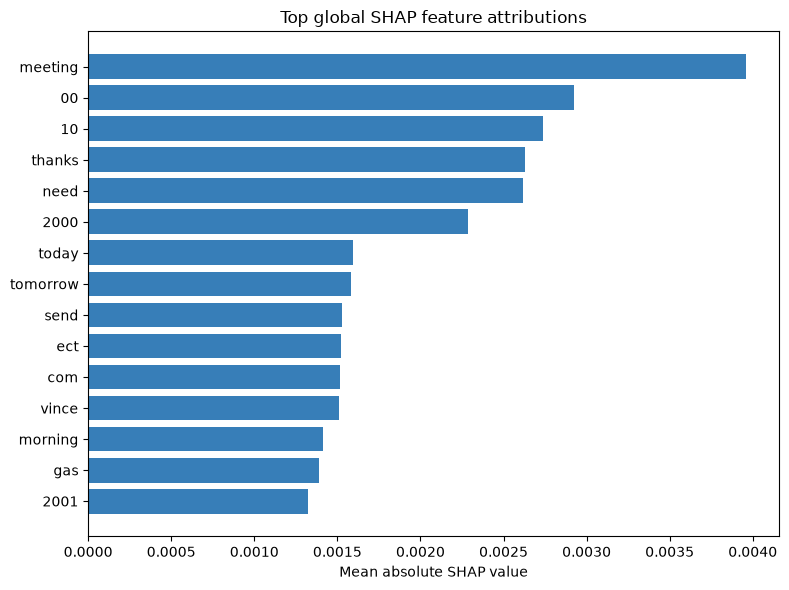

In [15]:
# I use mean absolute values for global magnitude; the CSV coefficient column retains direction.
top_global = global_importance.head(15).iloc[::-1]
figure, axis = plt.subplots(figsize=(8, 6))
axis.barh(top_global["feature"], top_global["mean_abs_shap"], color="#377eb8")
axis.set_title("Top global SHAP feature attributions")
axis.set_xlabel("Mean absolute SHAP value")
figure.tight_layout()
figure.savefig(FIGURES_DIR / "week4_shap_global.png", dpi=200, bbox_inches="tight")
plt.show()

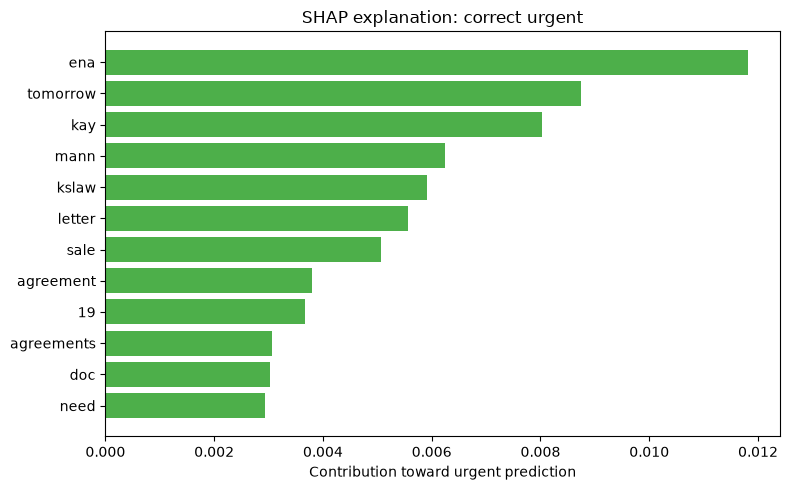

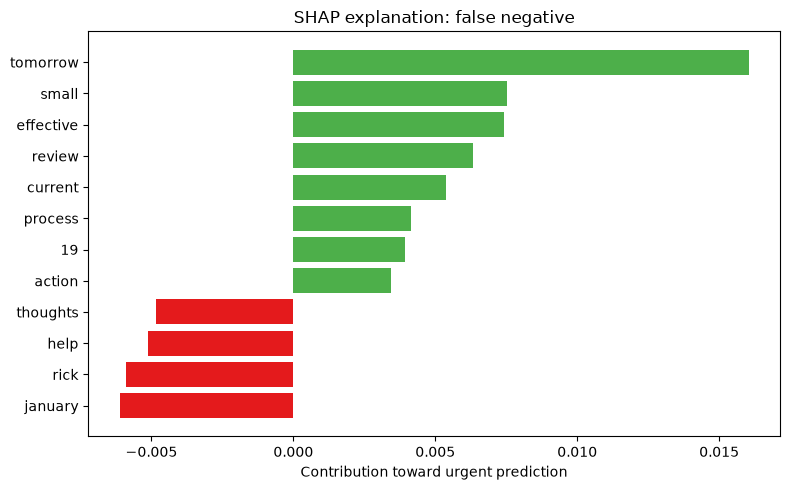

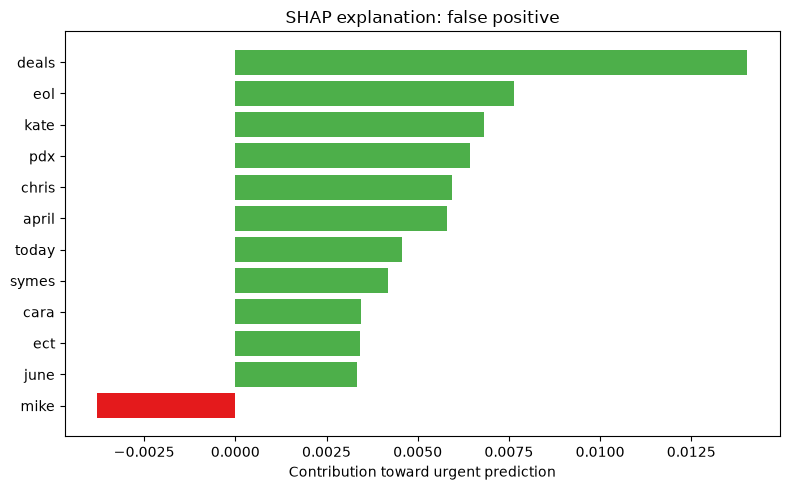

In [16]:
# I show one example of each available outcome type while retaining identifiers instead of message text.
local_cases = {
    "correct_urgent": (y_holdout == "urgent") & (selected_predictions == "urgent"),
    "false_negative": (y_holdout == "urgent") & (selected_predictions == "nonurgent"),
    "false_positive": (y_holdout == "nonurgent") & (selected_predictions == "urgent"),
}

for case_name, case_mask in local_cases.items():
    positions = np.flatnonzero(case_mask.to_numpy())
    if len(positions) == 0:
        print(f"No {case_name.replace('_', ' ')} example is available for the selected model.")
        continue
    position = positions[0]
    local_values = shap_matrix[position]
    top_positions = np.argsort(np.abs(local_values))[-12:]
    local_explanation = pd.DataFrame({
        "message_id": modeling_data.loc[X_holdout.index[position], "message_id"],
        "feature": feature_names[top_positions],
        "shap_value": local_values[top_positions],
    }).sort_values("shap_value")
    local_explanation.to_csv(METRICS_DIR / f"week4_shap_{case_name}.csv", index=False)

    figure, axis = plt.subplots(figsize=(8, 5))
    axis.barh(local_explanation["feature"], local_explanation["shap_value"], color=np.where(local_explanation["shap_value"] >= 0, "#4daf4a", "#e41a1c"))
    axis.set_title(f"SHAP explanation: {case_name.replace('_', ' ')}")
    axis.set_xlabel("Contribution toward urgent prediction")
    figure.tight_layout()
    figure.savefig(FIGURES_DIR / f"week4_shap_{case_name}.png", dpi=200, bbox_inches="tight")
    plt.show()

## 9. Model-Continuation Decision and Takeaways

### Continuation Decision

I retain a candidate only when it improves the primary cross-validation measure
and does not weaken the most important preliminary holdout safety measures. That
is a research decision for the next project step, not permission to automate
email handling.

In [17]:
# I apply the decision rule after reviewing both CV and holdout evidence.
# A candidate must improve CV urgent F1 and must not worsen preliminary holdout
# urgent F1, urgent recall, or urgent false negatives.
baseline_row = comparison.iloc[0]
selected_row = comparison.iloc[1]
candidate_cv_improved = (
    selected_cv_summary["cv_mean_f1_urgent"]
    > baseline_cv_summary["cv_mean_f1_urgent"]
)
selected_is_preferred = (
    candidate_cv_improved
    and selected_row["urgent_f1"] >= baseline_row["urgent_f1"]
    and selected_row["urgent_recall"] >= baseline_row["urgent_recall"]
    and selected_row["urgent_false_negatives"] <= baseline_row["urgent_false_negatives"]
)
decision = pd.DataFrame([{
    "selected_model": selected_row["model"] if selected_is_preferred else baseline_row["model"],
    "decision": "retain_week4_candidate" if selected_is_preferred else "retain_frozen_week3_baseline",
    "reason": "Candidate improved mean CV urgent F1 without regressing preliminary holdout urgent F1, recall, or false negatives." if selected_is_preferred else "Candidate did not meet the predefined cross-validation and urgent-class safety rule.",
    "holdout_interpretation": "Preliminary only; the Week 3 holdout informed prior exploratory selection.",
    "fairness_limitation": "No reliable protected demographic attributes are available for demographic fairness measurement.",
    "human_oversight": "Predictions remain decision support for a human reviewer, not automated email action.",
}])
decision.to_csv(METRICS_DIR / "week4_model_decision.csv", index=False)
display(decision)

,selected_model,decision,reason,holdout_interpretation,fairness_limitation,human_oversight
0,Week 4 GridSearchCV candidate,retain_week4_candidate,Candidate improved mean CV urgent F1 without r...,Preliminary only; the Week 3 holdout informed ...,No reliable protected demographic attributes a...,Predictions remain decision support for a huma...


## Takeaways

- The 24-configuration search selected class-balanced logistic regression with
  `C=0.1`, unigram TF-IDF, `min_df=2`, and sublinear term frequency.
- Mean five-fold cross-validation urgent F1 rose from 6.7% to 11.4%, and mean
  urgent recall rose from 4.0% to 8.0%. Each fold contains only about five
  urgent messages, so those estimates still vary substantially.
- The candidate matched the frozen baseline on the preliminary 40-message
  holdout: 87.5% accuracy, 66.7% urgent precision, 33.3% urgent recall, 44.4%
  urgent F1, and four urgent false negatives. It uses 1,202 fewer TF-IDF
  features.
- I retained the candidate for refinement because it improved cross-validation
  urgent F1 without weakening the preliminary holdout safety checks. The model
  is not deployment-ready.
- SHAP identifies learned feature associations, not causes of urgency. The
  dataset has no protected demographic attributes, so I cannot make demographic
  fairness claims. The next steps are more reviewed labels, related-message
  checks, and continued human review.